In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [2]:
LAT = 'tri'
nnx = 30
DIS = 'per'
mode = 'ductile'
nSim = 1

frame = 75

os.chdir('C:/Users/exy053/Documents/continuum/')

In [3]:
simDir = f'{mode.capitalize()}-{LAT}-{nnx}-{DIS}-{nSim}'
dispsCSV = f'{simDir}/frame{frame}.csv'
NodesElemsCSV = f'{simDir}/NodesElems.csv'

with open(NodesElemsCSV) as f:
    lines = f.readlines()
nodesStart = lines.index([line for line in lines if "*Nodes" in line][0])+1
elemsStart = lines.index([line for line in lines if "*Elems" in line][0])+1

disps = pd.read_csv(dispsCSV).to_numpy()
nodes = pd.read_csv(NodesElemsCSV, names=['node', 'x', 'y'], skiprows=nodesStart, nrows=elemsStart-2).to_numpy()
elems = pd.read_csv(NodesElemsCSV, names=['elem', 'n1', 'n2'], skiprows=elemsStart).to_numpy()

nodes

array([[  1.      , 277.128143, 270.      ],
       [  2.      , 268.467865, 265.      ],
       [  3.      , 268.467865, 255.      ],
       ...,
       [995.      , 251.147369, -15.      ],
       [996.      ,   0.      , 110.      ],
       [997.      , 277.128143, -30.      ]])

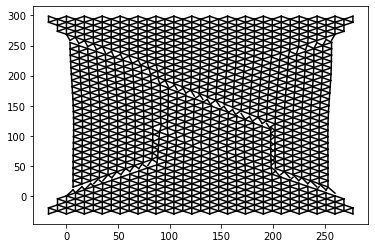

In [4]:
for elem in elems:
    n1 = elem[1]-1
    n2 = elem[2]-1
    plt.plot([nodes[n1][1]+disps[n1][1], nodes[n2][1]+disps[n2][1]], [nodes[n1][2]+disps[n1][2], nodes[n2][2]+disps[n1][2]], 'k')

In [5]:
from matplotlib.tri import Triangulation

# Now compute strain from the displacements (simplified example using finite differences)

# Compute strain using finite differences between neighboring nodes (simplified)
def compute_strain(node_coords, displacements):
    # Assuming node_coords is Nx2 and displacements is Nx2 (for Ux, Uy)
    num_nodes = len(node_coords)
    strains = np.zeros((num_nodes, 3))  # Placeholder for (Exx, Eyy, Exy) strains

    for i in range(num_nodes):
        # Basic finite difference method or more advanced FEM-based strain computation
        # Here you can compute Exx, Eyy, Exy based on the nodal displacements.
        # Placeholder: strains[i, :] = some_computation_function(...)
        pass

    return strains

# Call the strain computation function
strains = compute_strain(node_coords, np.vstack((x_displacements, y_displacements)).T)

# Visualize the strain (assuming you want to plot Exx as an example)
Exx = strains[:, 0]  # Extract the Exx strain component

# Generate a triangulation from node coordinates
tri = Triangulation(node_coords[:, 0], node_coords[:, 1])

# Plot the strain as a contour plot
plt.figure(figsize=(8, 6))
plt.tricontourf(tri, Exx, cmap='viridis')
plt.colorbar(label='Strain (Exx)')
plt.title('Strain (Exx) Contour Plot')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

NameError: name 'node_coords' is not defined